# Multi-device JAX: a 2-D wave equation with halo exchange

This notebook uses a periodic two-dimensional wave equation to introduce **single-host, multi-device numerical computing with JAX**. The global field is split into slabs, one per GPU. Each time step exchanges one boundary row with each neighbouring device and computes a global energy diagnostic.

The numerical problem is deliberately familiar. The new ideas are data placement, local versus global array views, point-to-point collectives, global reductions, validation across partition boundaries, and honest scaling measurements.

### Learning objectives

By the end of the notebook, you should be able to:

- describe a global array with a JAX device mesh and named sharding;
- derive the halo data needed by a finite-difference stencil;
- implement nearest-neighbour exchange with `jax.shard_map` and `jax.lax.ppermute`;
- use `jax.lax.psum` for a distributed diagnostic;
- distinguish correctness validation, compilation time, and steady-state execution time;
- explain when adding GPUs is likely to help—or hurt.

**Prerequisites:** NumPy/JAX array syntax, finite differences, and the leapfrog update used in `wave_equation.ipynb`. Allow about 75–90 minutes.

### Two execution modes

- On a machine with at least two GPUs, start Jupyter normally. JAX will use the visible devices.
- For development or CI on a CPU-only machine, start Jupyter with
  `JAX_MULTI_DEVICE_CPU_EMULATION=1 jupyter lab`. This creates four virtual CPU devices.

CPU emulation checks sharding and collective semantics. It is **not** evidence of multi-GPU performance.


In [1]:
import os
import time
from functools import partial

# These configuration changes must happen before the first device query.
import jax

EMULATE_CPU_DEVICES = os.environ.get(
    "JAX_MULTI_DEVICE_CPU_EMULATION", "0"
) == "1"
if EMULATE_CPU_DEVICES:
    jax.config.update("jax_platform_name", "cpu")
    jax.config.update("jax_num_cpu_devices", 4)

# Double precision makes the numerical validation easier to interpret.
# Many consumer GPUs have low float64 throughput; revisit this choice for production.
USE_X64 = os.environ.get("JAX_ENABLE_X64", "1") != "0"
jax.config.update("jax_enable_x64", USE_X64)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import lax
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

devices = np.asarray(jax.devices())
if devices.size < 2:
    raise RuntimeError(
        "This tutorial needs at least two devices. On a CPU-only machine, "
        "restart Jupyter with JAX_MULTI_DEVICE_CPU_EMULATION=1."
    )

array_dtype = np.float64 if USE_X64 else np.float32
print(f"JAX {jax.__version__}")
print(f"Backend: {jax.default_backend()}")
print(f"Devices ({devices.size}): {list(devices)}")
print(f"Array dtype: {array_dtype.__name__}")
print(f"CPU emulation: {EMULATE_CPU_DEVICES}")


JAX 0.6.2
Backend: cpu
Devices (4): [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Array dtype: float64
CPU emulation: True


## 1. From a global grid to local slabs

We solve

\[
\frac{\partial^2 u}{\partial t^2}
= c^2\left(\frac{\partial^2 u}{\partial x^2}
+ \frac{\partial^2 u}{\partial y^2}\right)
\]

on a periodic rectangle. A centred second-order stencil needs the four nearest neighbours of every grid point.

We partition only the first array dimension:

```text
global x direction

device 0       device 1                    device P-1
┌──────────┐   ┌──────────┐                ┌──────────┐
│ x-slab   │   │ x-slab   │      ...       │ x-slab   │
└──────────┘   └──────────┘                └──────────┘
       ── last row →     (left halo)
       ← first row ──     (right halo)
```

Every device owns all columns in the periodic \(y\) direction, so `jnp.roll` is local there. In the partitioned \(x\) direction, the first and last owned rows need values from neighbouring devices. Those rows are the **halos**.

This one-dimensional decomposition is easy to understand and often effective until each slab becomes too thin. A two-dimensional decomposition communicates less data per device for very large device counts, but it requires exchanges on two mesh axes and more bookkeeping.


In [2]:
AXIS_NAME = "devices"
mesh = Mesh(devices, (AXIS_NAME,))
field_spec = P(AXIS_NAME, None)
field_sharding = NamedSharding(mesh, field_spec)

print(mesh)
print(f"Global mesh size: {mesh.size}")
print(f"Field partitioning: {field_spec}")


Mesh('devices': 4, axis_types=(Auto,))
Global mesh size: 4
Field partitioning: PartitionSpec('devices', None)


`PartitionSpec("devices", None)` means “split array axis 0 over the mesh axis named `devices`; do not split array axis 1.” The specification describes a global array. Inside `shard_map`, each program instance sees only its local slab.

The grid size in the partitioned direction must be divisible by the device count in this notebook. Production codes often pad arrays or distribute uneven blocks when that restriction is inconvenient.


## 2. Reference discretisation and initial condition

For a periodic grid with spacings \(\Delta x\) and \(\Delta y\),

\[
(\nabla_h^2 u)_{i,j}
= \frac{u_{i-1,j}-2u_{i,j}+u_{i+1,j}}{\Delta x^2}
+ \frac{u_{i,j-1}-2u_{i,j}+u_{i,j+1}}{\Delta y^2}.
\]

The leapfrog update is

\[
u^{n+1}=2u^n-u^{n-1}+c^2\Delta t^2\nabla_h^2u^n.
\]

For stability in two dimensions, the centred scheme requires

\[
\left(\frac{c\Delta t}{\Delta x}\right)^2+
\left(\frac{c\Delta t}{\Delta y}\right)^2 \le 1.
\]

We use a standing Fourier mode with a known continuous solution. The distributed implementation will first be checked against the *same discrete algorithm* on one device; comparison with the continuous solution tests discretisation error separately.


In [3]:
def reference_laplacian(u, dx, dy):
    """Periodic five-point Laplacian on a global array."""
    d2x = (
        jnp.roll(u, 1, axis=0)
        - 2.0 * u
        + jnp.roll(u, -1, axis=0)
    ) / dx**2
    d2y = (
        jnp.roll(u, 1, axis=1)
        - 2.0 * u
        + jnp.roll(u, -1, axis=1)
    ) / dy**2
    return d2x + d2y


def reference_solver(
    u_initial, u_after_one_step, n_steps, *, c, dt, dx, dy
):
    """Leapfrog reference solver for a global, unsharded array."""
    def body(_, state):
        previous, current = state
        following = (
            2.0 * current
            - previous
            + (c * dt) ** 2
            * reference_laplacian(current, dx, dy)
        )
        return current, following

    return lax.fori_loop(
        1, n_steps, body, (u_initial, u_after_one_step)
    )


## 3. Halo exchange with `shard_map`

`jax.shard_map` maps a function over the shards of a global array. The mesh axis is marked manual because the function itself controls communication on that axis.

For device \(p\):

- its last row is sent to device \((p+1)\bmod P\), becoming that device's left halo;
- its first row is sent to device \((p-1)\bmod P\), becoming that device's right halo.

`lax.ppermute` expresses this cyclic point-to-point routing. On a GPU backend, JAX lowers the collective to the backend communication implementation; actual cost still depends on topology, interconnect, message size, and synchronization.


In [4]:
def make_distributed_operators(mesh, *, c, dt, dx, dy):
    """Build halo-aware Laplacian, energy reduction, and leapfrog solver."""
    n_devices = mesh.size
    send_right = tuple(
        (source, (source + 1) % n_devices)
        for source in range(n_devices)
    )
    send_left = tuple(
        (source, (source - 1) % n_devices)
        for source in range(n_devices)
    )

    @partial(
        jax.shard_map,
        mesh=mesh,
        in_specs=P(AXIS_NAME, None),
        out_specs=P(AXIS_NAME, None),
        axis_names={AXIS_NAME},
    )
    def distributed_laplacian(u_local):
        left_halo = lax.ppermute(
            u_local[-1], AXIS_NAME, send_right
        )
        right_halo = lax.ppermute(
            u_local[0], AXIS_NAME, send_left
        )
        padded = jnp.concatenate(
            (
                left_halo[None, :],
                u_local,
                right_halo[None, :],
            ),
            axis=0,
        )

        d2x = (
            padded[:-2]
            - 2.0 * padded[1:-1]
            + padded[2:]
        ) / dx**2
        d2y = (
            jnp.roll(u_local, 1, axis=1)
            - 2.0 * u_local
            + jnp.roll(u_local, -1, axis=1)
        ) / dy**2
        return d2x + d2y

    @partial(
        jax.shard_map,
        mesh=mesh,
        in_specs=(
            P(AXIS_NAME, None),
            P(AXIS_NAME, None),
        ),
        out_specs=P(),
        axis_names={AXIS_NAME},
    )
    def distributed_energy(u_previous_local, u_current_local):
        next_previous = lax.ppermute(
            u_previous_local[0], AXIS_NAME, send_left
        )
        next_current = lax.ppermute(
            u_current_local[0], AXIS_NAME, send_left
        )
        forward_previous = jnp.concatenate(
            (u_previous_local[1:], next_previous[None, :]),
            axis=0,
        )
        forward_current = jnp.concatenate(
            (u_current_local[1:], next_current[None, :]),
            axis=0,
        )

        velocity = (u_current_local - u_previous_local) / dt
        grad_x_previous = (
            forward_previous - u_previous_local
        ) / dx
        grad_x_current = (
            forward_current - u_current_local
        ) / dx
        grad_y_previous = (
            jnp.roll(u_previous_local, -1, axis=1)
            - u_previous_local
        ) / dy
        grad_y_current = (
            jnp.roll(u_current_local, -1, axis=1)
            - u_current_local
        ) / dy

        local_energy = (
            0.5
            * jnp.sum(
                velocity**2
                + c**2
                * (
                    grad_x_previous * grad_x_current
                    + grad_y_previous * grad_y_current
                )
            )
            * dx
            * dy
        )
        return lax.psum(local_energy, AXIS_NAME)

    @jax.jit
    def solve(u_initial, u_after_one_step, n_steps):
        def body(_, state):
            previous, current = state
            following = (
                2.0 * current
                - previous
                + (c * dt) ** 2
                * distributed_laplacian(current)
            )
            return current, following

        return lax.fori_loop(
            1, n_steps, body, (u_initial, u_after_one_step)
        )

    return distributed_laplacian, distributed_energy, solve


The global result of `distributed_laplacian` has the same sharding as its input. The energy is different: each device first computes a local contribution, `lax.psum` adds those contributions, and `out_specs=P()` declares the scalar replicated.

The energy expression uses gradients at adjacent time levels. That is intentional: it is the discrete invariant of this leapfrog discretisation. Sampling the familiar continuous energy at only one time level introduces an oscillatory diagnostic error and can misleadingly look like energy drift.


## 4. Place the global field on the mesh

The initial field is

\[
u(x,y,0)=\sin(k_xx)\sin(k_yy), \qquad u_t(x,y,0)=0,
\]

with exact solution

\[
u(x,y,t)=\cos\!\left(c\sqrt{k_x^2+k_y^2}\,t\right)
\sin(k_xx)\sin(k_yy).
\]

Initialisation is done on the host, then transferred once with the requested sharding. Repeated host-to-device transfers inside a time loop would be a serious performance bug.


In [5]:
NX = 128
NY = 128
LENGTH_X = 2.0 * np.pi
LENGTH_Y = 2.0 * np.pi
C = 1.0
KX = 1
KY = 2
FINAL_TIME = 0.5
TARGET_CFL = 0.5

if NX % mesh.size != 0:
    raise ValueError("NX must be divisible by the number of devices.")

dx = LENGTH_X / NX
dy = LENGTH_Y / NY
dt_limit = TARGET_CFL * min(dx, dy) / C
n_steps = int(np.ceil(FINAL_TIME / dt_limit))
dt = FINAL_TIME / n_steps
stability_number = (
    (C * dt / dx) ** 2 + (C * dt / dy) ** 2
)

x = np.arange(NX, dtype=array_dtype) * dx
y = np.arange(NY, dtype=array_dtype) * dy
xx, yy = np.meshgrid(x, y, indexing="ij")
u0_host = (
    np.sin(KX * xx) * np.sin(KY * yy)
).astype(array_dtype)

# A second-order first step for zero initial velocity.
lap0_host = (
    (
        np.roll(u0_host, 1, axis=0)
        - 2.0 * u0_host
        + np.roll(u0_host, -1, axis=0)
    )
    / dx**2
    + (
        np.roll(u0_host, 1, axis=1)
        - 2.0 * u0_host
        + np.roll(u0_host, -1, axis=1)
    )
    / dy**2
)
u1_host = u0_host + 0.5 * (C * dt) ** 2 * lap0_host

u0 = jax.device_put(u0_host, field_sharding)
u1 = jax.device_put(u1_host, field_sharding)

print(f"Grid: {NX} x {NY}")
print(f"Local slab: {NX // mesh.size} x {NY}")
print(f"Steps: {n_steps}, dt={dt:.5f}")
print(f"2-D stability number: {stability_number:.4f} <= 1")
for shard in u0.addressable_shards:
    print(f"{shard.device}: {shard.index}")


Grid: 128 x 128
Local slab: 32 x 128
Steps: 21, dt=0.02381
2-D stability number: 0.4705 <= 1
TFRT_CPU_0: (slice(0, 32, None), slice(None, None, None))
TFRT_CPU_1: (slice(32, 64, None), slice(None, None, None))
TFRT_CPU_2: (slice(64, 96, None), slice(None, None, None))
TFRT_CPU_3: (slice(96, 128, None), slice(None, None, None))


## 5. Validate the communication before integrating

A final solution can look plausible even when halo routing is wrong. We therefore test the distributed Laplacian directly against the global reference operator. This check exercises every partition boundary and the periodic wrap from the last device back to the first.


In [6]:
distributed_laplacian, distributed_energy, solve = (
    make_distributed_operators(
        mesh, c=C, dt=dt, dx=dx, dy=dy
    )
)

laplacian_distributed = distributed_laplacian(u0)
laplacian_reference = reference_laplacian(
    jnp.asarray(u0_host), dx, dy
)
laplacian_error = float(
    jnp.max(
        jnp.abs(
            laplacian_distributed - laplacian_reference
        )
    )
)

laplacian_tolerance = 1.0e-11 if USE_X64 else 2.0e-5
np.testing.assert_allclose(
    np.asarray(laplacian_distributed),
    np.asarray(laplacian_reference),
    rtol=laplacian_tolerance,
    atol=laplacian_tolerance,
)
print(f"Maximum Laplacian difference: {laplacian_error:.3e}")
print("Halo-exchange check passed.")


Maximum Laplacian difference: 0.000e+00
Halo-exchange check passed.


## 6. Integrate and compare three questions

We now keep three distinct checks separate:

1. **Did distribution change the algorithm?** Compare with the same leapfrog scheme on a global array.
2. **Does the discretisation approximate the PDE?** Compare with the continuous exact mode.
3. **Does the time integrator preserve its discrete invariant?** Compare global energy at the first and last half steps.

The first call includes compilation. Timings later in the notebook warm up every compiled case before measurement.


In [7]:
# Distributed solve: returns the last two time levels.
u_previous, u_final = solve(u0, u1, n_steps)
u_final.block_until_ready()

# Same discrete algorithm on a global array.
reference_solve_jit = jax.jit(
    partial(
        reference_solver,
        c=C,
        dt=dt,
        dx=dx,
        dy=dy,
    )
)
reference_previous, reference_final = reference_solve_jit(
    jnp.asarray(u0_host),
    jnp.asarray(u1_host),
    n_steps,
)
reference_final.block_until_ready()

omega = C * np.sqrt(KX**2 + KY**2)
exact_final = np.cos(omega * FINAL_TIME) * u0_host
u_final_host = np.asarray(u_final)

distributed_difference = float(
    np.max(
        np.abs(
            u_final_host - np.asarray(reference_final)
        )
    )
)
continuous_l2_error = float(
    np.sqrt(np.mean((u_final_host - exact_final) ** 2))
)

energy_initial = float(distributed_energy(u0, u1))
energy_final = float(
    distributed_energy(u_previous, u_final)
)
relative_energy_drift = abs(
    energy_final - energy_initial
) / abs(energy_initial)

print(
    "Distributed versus reference max difference: "
    f"{distributed_difference:.3e}"
)
print(
    "Continuous-solution RMS error: "
    f"{continuous_l2_error:.3e}"
)
print(f"Initial discrete energy: {energy_initial:.12e}")
print(f"Final discrete energy:   {energy_final:.12e}")
print(f"Relative energy drift:   {relative_energy_drift:.3e}")


Distributed versus reference max difference: 0.000e+00
Continuous-solution RMS error: 1.122e-04
Initial discrete energy: 2.463971037423e+01
Final discrete energy:   2.463971037423e+01
Relative energy drift:   2.884e-16


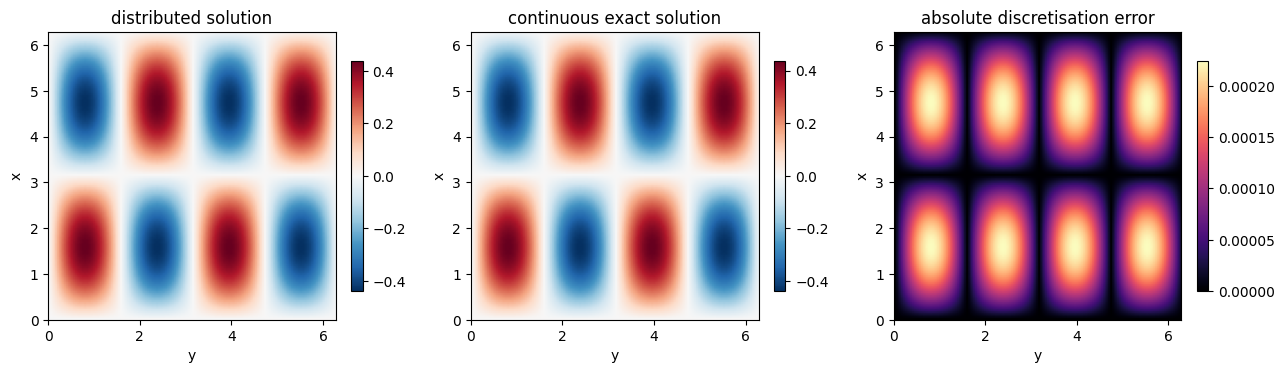

In [8]:
fig, axes = plt.subplots(
    1, 3, figsize=(13, 3.6), constrained_layout=True
)
extent = (0.0, LENGTH_Y, 0.0, LENGTH_X)

panels = (
    (u_final_host, "distributed solution", "RdBu_r"),
    (exact_final, "continuous exact solution", "RdBu_r"),
    (
        np.abs(u_final_host - exact_final),
        "absolute discretisation error",
        "magma",
    ),
)
for axis, (field, title, cmap) in zip(axes, panels):
    image = axis.imshow(
        field,
        origin="lower",
        extent=extent,
        aspect="equal",
        cmap=cmap,
    )
    axis.set_title(title)
    axis.set_xlabel("y")
    axis.set_ylabel("x")
    fig.colorbar(image, ax=axis, shrink=0.8)

plt.show()


The full field is copied to the host only after integration for plotting and validation. During the solve, each device retains its slab and exchanges only two rows per step.

The exact-solution error is not expected to be zero: both the five-point Laplacian and leapfrog time stepping have second-order truncation error. The distributed-versus-reference difference should be at round-off level because both execute the same discrete update.


## 7. Exercise: what if every slab pretends to be periodic?

Before running the next cell, predict where the error will be largest if `jnp.roll` is used along the *local* first axis instead of exchanging halos.

This is a common parallelisation bug: every local slab becomes its own small periodic domain. The computation remains fast and produces smooth-looking values away from interfaces, so visual inspection alone may miss it.

The cell below is a complete solution. It constructs the broken operator deliberately, integrates it, and compares interface rows with the correct result.


In [9]:
@partial(
    jax.shard_map,
    mesh=mesh,
    in_specs=P(AXIS_NAME, None),
    out_specs=P(AXIS_NAME, None),
    axis_names={AXIS_NAME},
)
def broken_local_periodic_laplacian(u_local):
    d2x = (
        jnp.roll(u_local, 1, axis=0)
        - 2.0 * u_local
        + jnp.roll(u_local, -1, axis=0)
    ) / dx**2
    d2y = (
        jnp.roll(u_local, 1, axis=1)
        - 2.0 * u_local
        + jnp.roll(u_local, -1, axis=1)
    ) / dy**2
    return d2x + d2y


@jax.jit
def solve_with_broken_halos(
    u_initial, u_after_one_step, n_steps
):
    def body(_, state):
        previous, current = state
        following = (
            2.0 * current
            - previous
            + (C * dt) ** 2
            * broken_local_periodic_laplacian(current)
        )
        return current, following

    return lax.fori_loop(
        1, n_steps, body, (u_initial, u_after_one_step)
    )


_, broken_final = solve_with_broken_halos(u0, u1, n_steps)
broken_final_host = np.asarray(broken_final)
broken_error = np.abs(broken_final_host - u_final_host)
broken_operator = broken_local_periodic_laplacian(u0)
operator_defect = np.abs(
    np.asarray(broken_operator)
    - np.asarray(laplacian_distributed)
)

local_nx = NX // mesh.size
boundaries = np.arange(0, NX, local_nx)
interface_rows = np.unique(
    np.concatenate(((boundaries - 1) % NX, boundaries))
)
non_interface_mask = np.ones(NX, dtype=bool)
non_interface_mask[interface_rows] = False

interface_operator_defect = float(
    np.mean(operator_defect[interface_rows, :])
)
interior_operator_defect = float(
    np.max(operator_defect[non_interface_mask, :])
)
final_rms_difference = float(
    np.sqrt(np.mean(broken_error**2))
)
print(
    "Immediate mean defect on interface rows: "
    f"{interface_operator_defect:.3e}"
)
print(
    "Immediate maximum defect elsewhere:      "
    f"{interior_operator_defect:.3e}"
)
print(
    "Final global RMS solution difference:    "
    f"{final_rms_difference:.3e}"
)


Immediate mean defect on interface rows: 2.638e+02
Immediate maximum defect elsewhere:      0.000e+00
Final global RMS solution difference:    2.171e-01


**Interpretation.** The largest immediate defects occur at slab boundaries, because those rows use values from the wrong physical location. Wave propagation then carries the damage into slab interiors. A good distributed test suite should therefore include operator-level checks at every boundary, not only a final norm.


## 8. Optional real-GPU strong-scaling experiment

Strong scaling keeps the **global grid fixed** while increasing the device count. That is the honest test for “does adding GPUs make this one problem faster?”

The following cell is disabled by default. Run Jupyter with `RUN_JAX_MULTI_GPU_BENCHMARK=1` on a GPU system to enable it. Each case is compiled and warmed up before three steady-state measurements. CPU-emulation timings are intentionally rejected.

The default \(2048^2\) grid may still be too small to amortise communication and launch overhead on fast GPUs. Increase it until the single-device case runs long enough to measure reliably, while monitoring device memory.


In [10]:
RUN_GPU_BENCHMARK = (
    os.environ.get("RUN_JAX_MULTI_GPU_BENCHMARK", "0") == "1"
)


def benchmark_case(
    case_devices, *, nx=2048, ny=2048, steps=100, repeats=3
):
    if nx % len(case_devices) != 0:
        raise ValueError("nx must be divisible by the device count.")

    case_mesh = Mesh(
        np.asarray(case_devices), (AXIS_NAME,)
    )
    case_sharding = NamedSharding(
        case_mesh, P(AXIS_NAME, None)
    )
    case_dx = LENGTH_X / nx
    case_dy = LENGTH_Y / ny
    case_dt = 0.45 * min(case_dx, case_dy) / C

    case_x = np.arange(nx, dtype=array_dtype) * case_dx
    case_y = np.arange(ny, dtype=array_dtype) * case_dy
    case_xx, case_yy = np.meshgrid(
        case_x, case_y, indexing="ij"
    )
    case_u0_host = (
        np.sin(KX * case_xx) * np.sin(KY * case_yy)
    ).astype(array_dtype)
    case_lap0 = (
        (
            np.roll(case_u0_host, 1, axis=0)
            - 2.0 * case_u0_host
            + np.roll(case_u0_host, -1, axis=0)
        )
        / case_dx**2
        + (
            np.roll(case_u0_host, 1, axis=1)
            - 2.0 * case_u0_host
            + np.roll(case_u0_host, -1, axis=1)
        )
        / case_dy**2
    )
    case_u1_host = (
        case_u0_host
        + 0.5 * (C * case_dt) ** 2 * case_lap0
    )
    case_u0 = jax.device_put(
        case_u0_host, case_sharding
    )
    case_u1 = jax.device_put(
        case_u1_host, case_sharding
    )

    _, _, case_solve = make_distributed_operators(
        case_mesh,
        c=C,
        dt=case_dt,
        dx=case_dx,
        dy=case_dy,
    )

    # Compile and warm up; do not include this call in timings.
    case_solve(
        case_u0, case_u1, steps
    )[1].block_until_ready()

    elapsed = []
    for _ in range(repeats):
        started = time.perf_counter()
        result = case_solve(case_u0, case_u1, steps)[1]
        result.block_until_ready()
        elapsed.append(time.perf_counter() - started)

    return float(np.median(elapsed))


if not RUN_GPU_BENCHMARK:
    print(
        "GPU benchmark disabled. Set "
        "RUN_JAX_MULTI_GPU_BENCHMARK=1 before starting Jupyter."
    )
elif jax.default_backend() != "gpu":
    print(
        "Benchmark skipped: CPU emulation validates semantics, "
        "not GPU scaling."
    )
else:
    counts = [
        count
        for count in range(1, devices.size + 1)
        if devices.size % count == 0
    ]
    scaling = [
        (count, benchmark_case(devices[:count]))
        for count in counts
    ]
    baseline = scaling[0][1]

    print("devices   seconds   speedup   efficiency")
    for count, seconds in scaling:
        speedup = baseline / seconds
        efficiency = speedup / count
        print(
            f"{count:7d}   {seconds:7.4f}   "
            f"{speedup:7.2f}   {efficiency:10.1%}"
        )


GPU benchmark disabled. Set RUN_JAX_MULTI_GPU_BENCHMARK=1 before starting Jupyter.


### How to interpret the scaling table

Ideal strong scaling would halve runtime when the device count doubles. Real stencil codes stop scaling ideally because:

- local computation shrinks with slab width, while two halo messages are still required per step;
- every step synchronises neighbouring devices;
- small kernels and collectives pay launch latency;
- PCIe-connected GPUs communicate differently from GPUs joined by a high-bandwidth fabric;
- the one-dimensional decomposition eventually produces thin slabs;
- compilation, initial placement, plotting, and host transfers are separate costs and should not be hidden inside the steady-state number.

A slowdown is not necessarily a JAX failure. It may mean the problem is too small, the decomposition is unsuitable, or the machine topology makes communication dominant. Report grid size, precision, step count, device model, interconnect, JAX/jaxlib versions, and whether compilation was excluded.


## 9. From one host to several hosts

The numerical decomposition does not fundamentally change across hosts, but process setup does. Every process must call `jax.distributed.initialize()` **before any device query or computation**, and every process must participate in the same distributed program. Scheduler-specific coordinates and process counts must be configured consistently.

This notebook queries devices near the top, so it cannot be converted to multi-host execution by inserting `initialize()` later. Put initialisation in the first executable cell or, preferably, in a batch entry-point script. Multi-host runs also add network topology, process failure, launch, and filesystem concerns that CPU emulation cannot test.

See JAX's official [multi-process documentation](https://docs.jax.dev/en/latest/multi_process.html) before adapting this example.


## 10. Design exercise: when should the mesh become two-dimensional?

Suppose the grid and device count grow until each x-slab is very thin.

**Question.** Sketch a two-dimensional decomposition for an \(N_x\times N_y\) field. What must change in the sharding specification and halo exchange? What new communication is required for a nine-point stencil?

**Solution.**

- Arrange devices as a two-axis mesh, for example `Mesh(device_array, ("x", "y"))`.
- Use `P("x", "y")` so both field axes are partitioned.
- Exchange left/right faces along mesh axis `"x"` and lower/upper faces along `"y"`.
- A five-point stencil needs only those four face halos.
- A nine-point stencil also uses diagonal neighbours. Either exchange corner values directly or perform staged face exchanges that include newly received halo data.
- Choose the mesh shape using both the global grid aspect ratio and the physical device topology. A square logical mesh is not automatically optimal.
- Revalidate the local operator at faces, corners, and periodic wraps; a global norm alone can hide routing errors.

The advantage is a smaller communicated perimeter for each local two-dimensional block at high device counts. The disadvantages are more collectives, more complicated indexing, and a greater risk of mapping logical neighbours poorly onto the hardware interconnect.


## 11. Final validation

These checks encode scientific invariants and distributed correctness. They deliberately make no assertion about speed: performance is hardware- and problem-dependent.


In [11]:
solution_tolerance = 2.0e-11 if USE_X64 else 2.0e-4
energy_tolerance = 2.0e-11 if USE_X64 else 5.0e-5

assert stability_number <= 1.0
assert distributed_difference < solution_tolerance
assert continuous_l2_error < 2.0e-3
assert relative_energy_drift < energy_tolerance
assert interface_operator_defect > 1.0e-4
assert interior_operator_defect < laplacian_tolerance
assert final_rms_difference > 1.0e-4

print("All numerical and distributed-correctness checks passed.")


All numerical and distributed-correctness checks passed.


## Takeaways

- A sharding specification describes how a global array is placed; `shard_map` exposes the local computation on each shard.
- Partitioned finite-difference stencils need explicit halo exchange. Local `jnp.roll` is correct only along an unpartitioned periodic axis.
- `lax.ppermute` expresses neighbour routing, while `lax.psum` constructs a replicated global reduction.
- Validate the distributed operator against an unsharded reference before trusting a full simulation.
- Keep arrays resident on devices throughout the time loop. Gather only diagnostics or final results that genuinely need the host.
- Multi-GPU execution helps only when the local work amortises communication and synchronization. Strong-scaling measurements, not device count, decide whether it helped.

### Further reading

- JAX: [Distributed arrays and automatic parallelisation](https://docs.jax.dev/en/latest/201/sharding.html)
- JAX: [Manual parallelism with `shard_map`](https://docs.jax.dev/en/latest/notebooks/shard_map.html)
- JAX API: [`jax.lax.ppermute`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.ppermute.html)
- JAX: [Multi-process and multi-host execution](https://docs.jax.dev/en/latest/multi_process.html)
- JAX: [GPU performance tips](https://docs.jax.dev/en/latest/gpu_performance_tips.html)
